In [1]:
# Ensure 'src' is on sys.path so imports work
import sys
from pathlib import Path

# Notebook lives in '<repo>/src/notebooks', so parent is '<repo>/src'
SRC_DIR = Path.cwd().parent
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print(f"Added to sys.path: {SRC_DIR}")

Added to sys.path: /Users/jelenajovanovic/Desktop/SADA/AIML/CHURN


In [2]:
from etl import download_dataset

download_dataset("blastchar/telco-customer-churn", unzip=True)

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
Download complete!


PosixPath('/Users/jelenajovanovic/Desktop/SADA/AIML/CHURN/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
import pandas as pd
from pathlib import Path

# Build path relative to SRC_DIR (set in Cell 1)
DATA_PATH = Path(SRC_DIR) / "data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
print(f"Loading: {DATA_PATH}")
churn_dt = pd.read_csv(DATA_PATH)
churn_dt.head()

Loading: /Users/jelenajovanovic/Desktop/SADA/AIML/CHURN/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
import sys

print(sys.path)

['/Users/jelenajovanovic/Desktop/SADA/AIML/CHURN', '/opt/homebrew/Cellar/python@3.13/3.13.5/Frameworks/Python.framework/Versions/3.13/lib/python313.zip', '/opt/homebrew/Cellar/python@3.13/3.13.5/Frameworks/Python.framework/Versions/3.13/lib/python3.13', '/opt/homebrew/Cellar/python@3.13/3.13.5/Frameworks/Python.framework/Versions/3.13/lib/python3.13/lib-dynload', '', '/Users/jelenajovanovic/Desktop/SADA/AIML/CHURN/.venv/lib/python3.13/site-packages', '/Users/jelenajovanovic/Desktop/SADA/AIML/CHURN/src']


In [5]:
import ydata_profiling as yp
from pathlib import Path

# Ensure output directory exists under src/reports
REPORTS_DIR = Path(SRC_DIR) / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
output_file = REPORTS_DIR / "churn_report.html"

report = yp.ProfileReport(churn_dt)
report.to_file(output_file)
print(f"Report written to: {output_file}")


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 21/21 [00:00<00:00, 315.87it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Report written to: /Users/jelenajovanovic/Desktop/SADA/AIML/CHURN/reports/churn_report.html


In [6]:
import numpy as np
# NumPy 2.x compatibility: older libs expect np.VisibleDeprecationWarning
if not hasattr(np, "VisibleDeprecationWarning"):
    try:
        from numpy.exceptions import VisibleDeprecationWarning as _VDW
        np.VisibleDeprecationWarning = _VDW
    except Exception:
        class _VDW(Warning):
            pass
        np.VisibleDeprecationWarning = _VDW

import sweetviz as sv
from pathlib import Path

# Save Sweetviz report under src/reports
REPORTS_DIR = Path(SRC_DIR) / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
output_file = REPORTS_DIR / "sweetviz_report.html"

sv.analyze(churn_dt, target_feat="Churn").show_html(filepath=str(output_file), open_browser=False)
print(f"Sweetviz report written to: {output_file}")


                                             |          | [  0%]   00:00 -> (? left)

Report /Users/jelenajovanovic/Desktop/SADA/AIML/CHURN/reports/sweetviz_report.html was generated.
Sweetviz report written to: /Users/jelenajovanovic/Desktop/SADA/AIML/CHURN/reports/sweetviz_report.html


In [7]:
# Transform categorical columns to binary (1/0)
churn_dt['gender'] = churn_dt['gender'].map({'Female': 1, 'Male': 0})
churn_dt['Partner'] = churn_dt['Partner'].map({'Yes': 1, 'No': 0})
churn_dt['Dependents'] = churn_dt['Dependents'].map({'Yes': 1, 'No': 0})
# SeniorCitizen is already 0/1

# Verify the transformations
churn_dt[['gender', 'SeniorCitizen', 'Partner', 'Dependents']].head(10)

,gender,SeniorCitizen,Partner,Dependents
0,1,0,1,0
1,0,0,0,0
2,0,0,0,0
3,0,0,0,0
4,1,0,0,0
5,1,0,0,0
6,0,0,0,1
7,1,0,0,0
8,1,0,1,0
9,0,0,0,1


In [8]:
# Define service columns
service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                'TechSupport', 'StreamingTV', 'StreamingMovies']

# Create binary service indicators (1 = has service, 0 = no service)
for col in service_cols:
    churn_dt[f'{col}_flag'] = churn_dt[col].apply(
        lambda x: 1 if x not in ['No', 'No phone service', 'No internet service'] else 0
    )

# Calculate total services per customer
service_flag_cols = [f'{col}_flag' for col in service_cols]
churn_dt['total_services'] = churn_dt[service_flag_cols].sum(axis=1)

# Convert TotalCharges to numeric (handle empty strings)
churn_dt['TotalCharges'] = pd.to_numeric(churn_dt['TotalCharges'], errors='coerce')

# Group by demographics and calculate aggregations
demo_group = churn_dt.groupby(['gender', 'SeniorCitizen', 'Partner', 'Dependents']).agg(
    customer_count=('customerID', 'count'),
    avg_services=('total_services', 'mean'),
    avg_monthly_charges=('MonthlyCharges', 'mean'),
    avg_total_charges=('TotalCharges', 'mean'),
    total_revenue=('TotalCharges', 'sum')
).round(2).reset_index()

demo_group

,gender,SeniorCitizen,Partner,Dependents,customer_count,avg_services,avg_monthly_charges,avg_total_charges,total_revenue
0,0,0,0,0,1381,3.52,58.98,1488.73,2055933.40
1,0,0,0,1,211,3.23,49.83,1395.84,291730.55
2,0,0,1,0,567,5.05,73.53,3385.66,1919671.30
3,0,0,1,1,822,4.27,60.76,2738.40,2240010.55
4,0,1,0,0,244,4.20,74.90,1971.32,481001.60
5,0,1,0,1,5,3.60,65.14,1884.51,9422.55
6,0,1,1,0,281,4.97,80.96,3266.16,917792.15
7,0,1,1,1,44,5.70,84.80,4278.46,188252.40
8,1,0,0,0,1338,3.73,61.30,1549.85,2073697.30
9,1,0,0,1,142,3.51,55.20,1245.80,176903.35


In [9]:
demo_group = demo_group.reset_index()

In [10]:
demo_group

,index,gender,SeniorCitizen,Partner,Dependents,customer_count,avg_services,avg_monthly_charges,avg_total_charges,total_revenue
0,0,0,0,0,0,1381,3.52,58.98,1488.73,2055933.40
1,1,0,0,0,1,211,3.23,49.83,1395.84,291730.55
2,2,0,0,1,0,567,5.05,73.53,3385.66,1919671.30
3,3,0,0,1,1,822,4.27,60.76,2738.40,2240010.55
4,4,0,1,0,0,244,4.20,74.90,1971.32,481001.60
5,5,0,1,0,1,5,3.60,65.14,1884.51,9422.55
6,6,0,1,1,0,281,4.97,80.96,3266.16,917792.15
7,7,0,1,1,1,44,5.70,84.80,4278.46,188252.40
8,8,1,0,0,0,1338,3.73,61.30,1549.85,2073697.30
9,9,1,0,0,1,142,3.51,55.20,1245.80,176903.35


### DQ1. How do customer demographics relate to service adoption?
- How does the average number of subscribed services differ by gender, senior status, partnership, and dependents?
- Are customers with partners and/or dependents more likely to subscribe to multiple services?


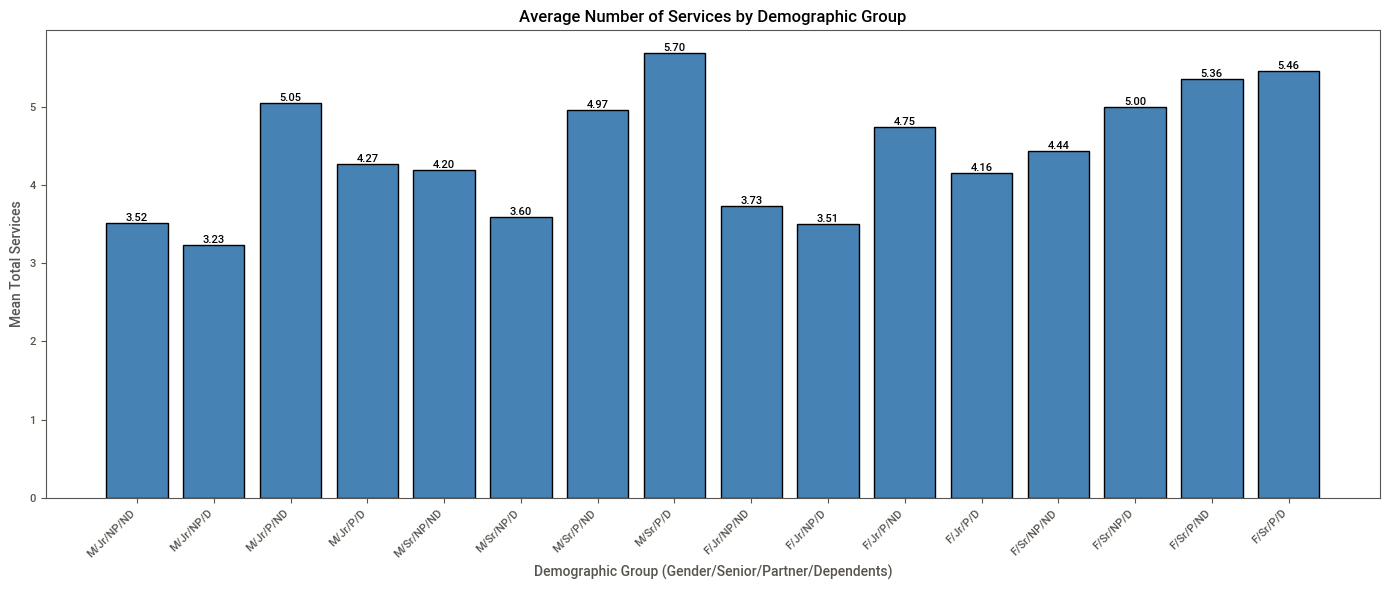

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# Create demographic group labels for better readability
demo_group['demo_label'] = (
    demo_group['gender'].map({1: 'F', 0: 'M'}) + '/' +
    demo_group['SeniorCitizen'].map({1: 'Sr', 0: 'Jr'}) + '/' +
    demo_group['Partner'].map({1: 'P', 0: 'NP'}) + '/' +
    demo_group['Dependents'].map({1: 'D', 0: 'ND'})
)

# Aggregate to get mean services per demographic combination
demo_avg = demo_group.groupby(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'demo_label']).agg(
    avg_services=('avg_services', 'mean')
).reset_index()

# Plot: Average Number of Services by Demographic Group
plt.figure(figsize=(14, 6))
bars = plt.bar(demo_avg['demo_label'], demo_avg['avg_services'], color='steelblue', edgecolor='black')
plt.xlabel('Demographic Group (Gender/Senior/Partner/Dependents)')
plt.ylabel('Mean Total Services')
plt.title('Average Number of Services by Demographic Group')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', 
             ha='center', va='bottom', fontsize=8)

plt.show()

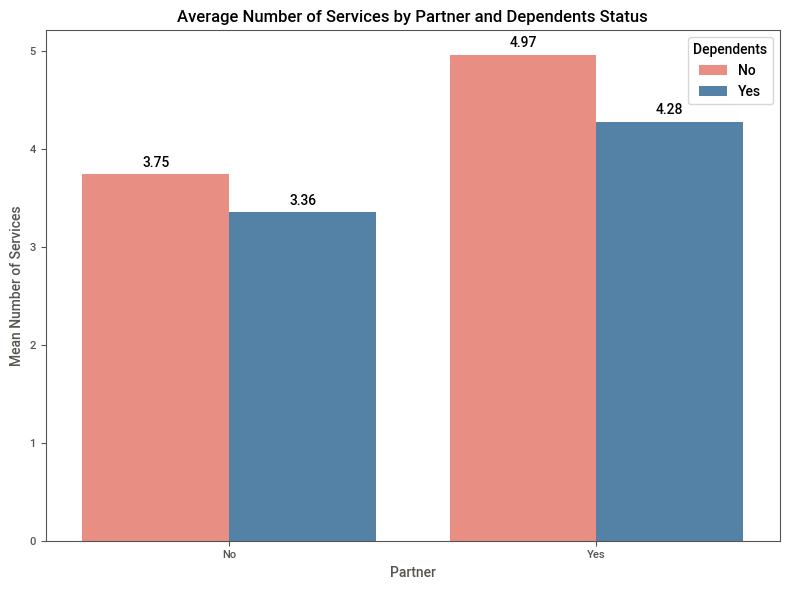

In [12]:
# Plot 2: Mean Services by Partner and Dependents (Grouped Bar)
partner_dep_services = churn_dt.groupby(['Partner', 'Dependents']).agg(
    mean_services=('total_services', 'mean')
).reset_index()

# Map to readable labels
partner_dep_services['Partner'] = partner_dep_services['Partner'].map({0: 'No', 1: 'Yes'})
partner_dep_services['Dependents'] = partner_dep_services['Dependents'].map({0: 'No', 1: 'Yes'})

plt.figure(figsize=(8, 6))
sns.barplot(data=partner_dep_services, x='Partner', y='mean_services', hue='Dependents', palette=['salmon', 'steelblue'])
plt.xlabel('Partner')
plt.ylabel('Mean Number of Services')
plt.title('Average Number of Services by Partner and Dependents Status')
plt.legend(title='Dependents')

# Add value labels
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

### DQ2. How do demographic groups differ in spending behavior?
- How do average monthly charges and total charges vary across demographic segments?
- Do seniors pay more on average despite having fewer services?


/var/folders/72/fp6wrfpj3yz_61z312xbn6kr0000gn/T/ipykernel_87080/405920346.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=churn_dt, x='demo_label', y='MonthlyCharges', ax=axes[0], palette='Set2')
/var/folders/72/fp6wrfpj3yz_61z312xbn6kr0000gn/T/ipykernel_87080/405920346.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=churn_dt, x='demo_label', y='TotalCharges', ax=axes[1], palette='Set2')


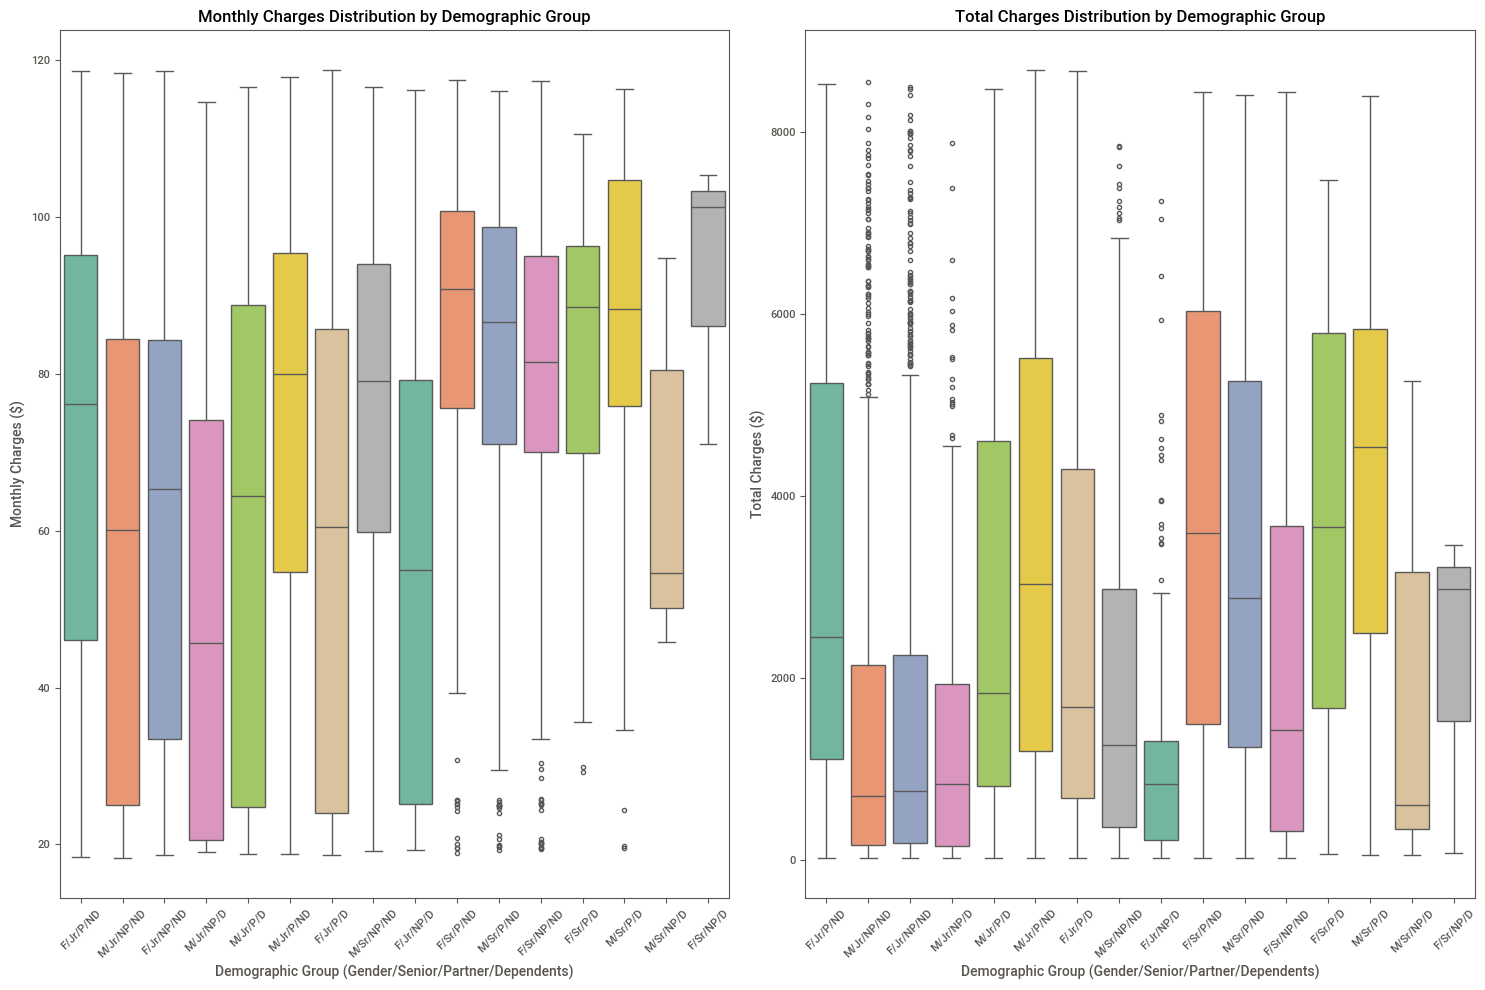

In [13]:
# Plot 3: Boxplots - Charges by Demographic Group
# Create demographic label for each customer
churn_dt['demo_label'] = (
    churn_dt['gender'].map({1: 'F', 0: 'M'}) + '/' +
    churn_dt['SeniorCitizen'].map({1: 'Sr', 0: 'Jr'}) + '/' +
    churn_dt['Partner'].map({1: 'P', 0: 'NP'}) + '/' +
    churn_dt['Dependents'].map({1: 'D', 0: 'ND'})
)

fig, axes = plt.subplots(1, 2, figsize=(15, 10))

# Top: MonthlyCharges by demographic
sns.boxplot(data=churn_dt, x='demo_label', y='MonthlyCharges', ax=axes[0], palette='Set2')
axes[0].set_xlabel('Demographic Group (Gender/Senior/Partner/Dependents)')
axes[0].set_ylabel('Monthly Charges ($)')
axes[0].set_title('Monthly Charges Distribution by Demographic Group')
axes[0].tick_params(axis='x', rotation=45)

# Bottom: TotalCharges by demographic
sns.boxplot(data=churn_dt, x='demo_label', y='TotalCharges', ax=axes[1], palette='Set2')
axes[1].set_xlabel('Demographic Group (Gender/Senior/Partner/Dependents)')
axes[1].set_ylabel('Total Charges ($)')
axes[1].set_title('Total Charges Distribution by Demographic Group')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

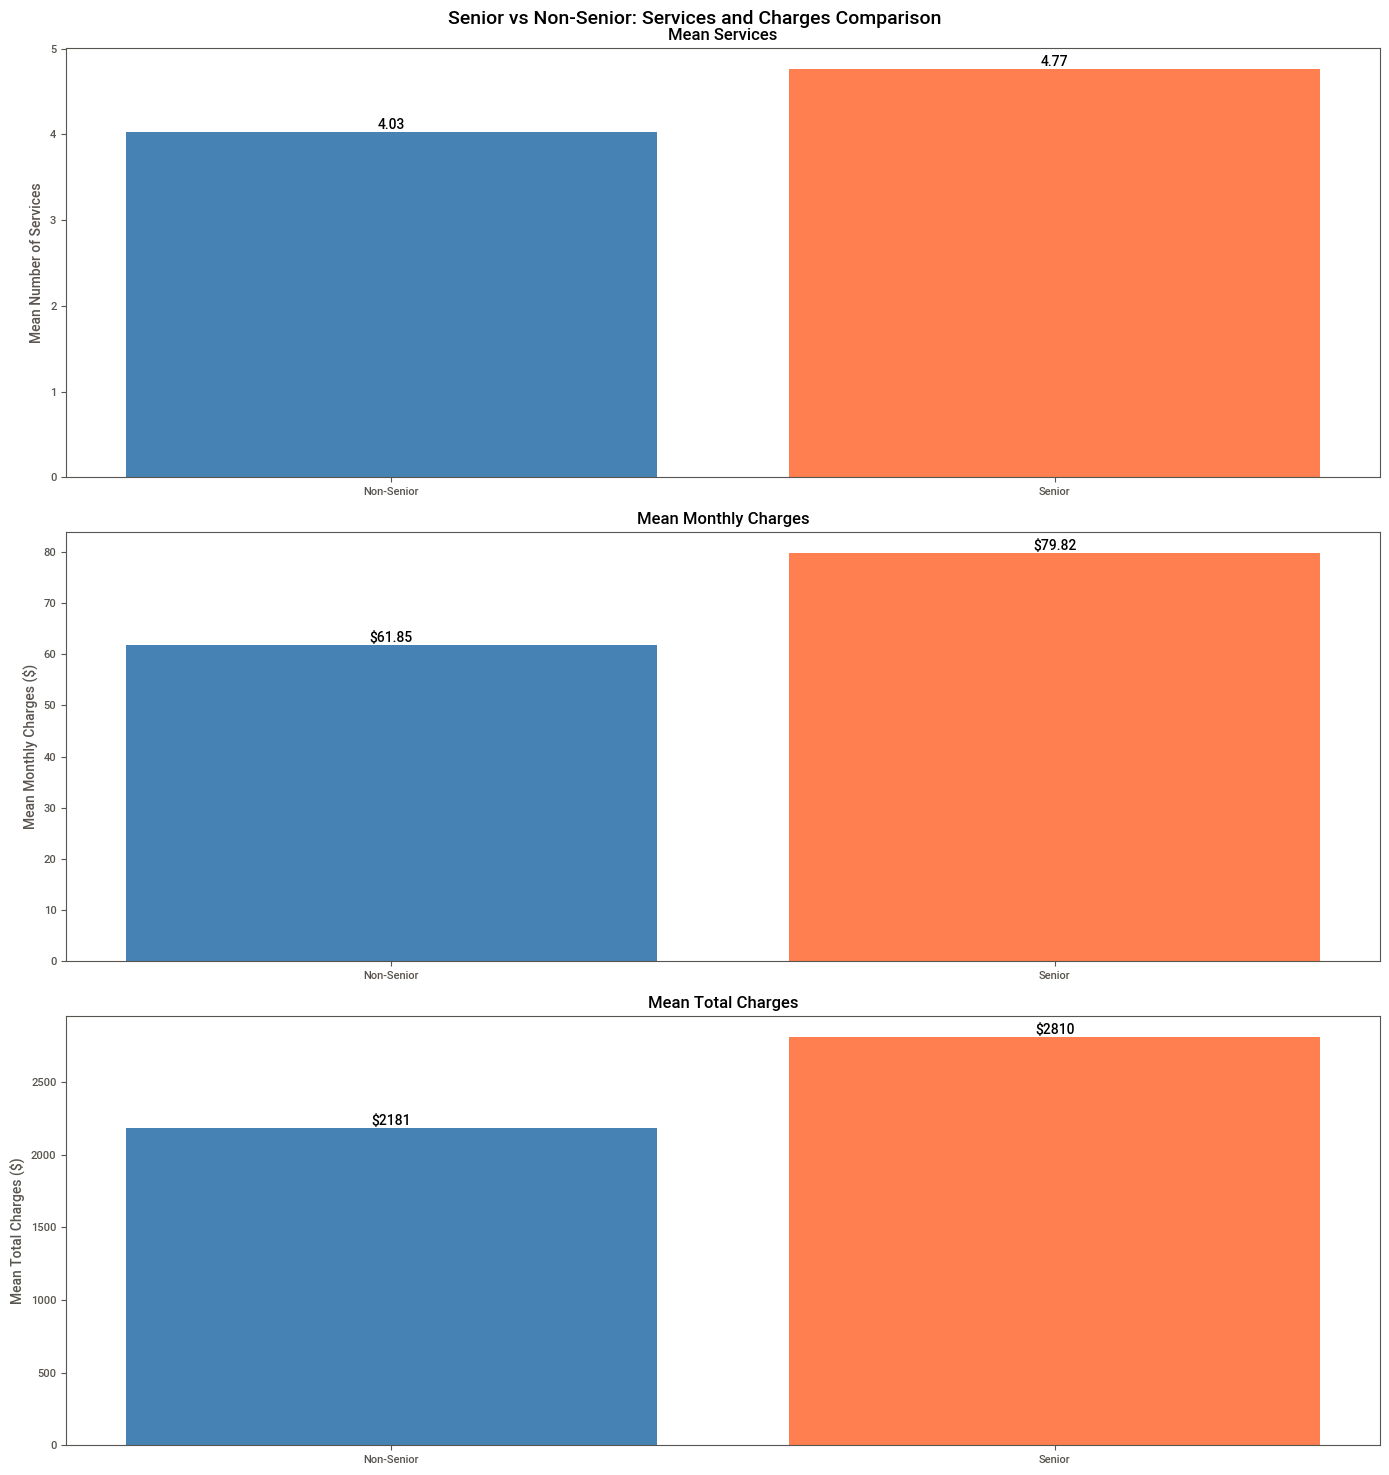

In [14]:
# Plot 4: Senior vs Non-Senior Comparison (Side-by-Side Bar Plots)
senior_stats = churn_dt.groupby('SeniorCitizen').agg(
    mean_services=('total_services', 'mean'),
    mean_monthly=('MonthlyCharges', 'mean'),
    mean_total=('TotalCharges', 'mean')
).reset_index()
senior_stats['SeniorCitizen'] = senior_stats['SeniorCitizen'].map({0: 'Non-Senior', 1: 'Senior'})

fig, axes = plt.subplots(3, 1, figsize=(14, 15))
colors = ['steelblue', 'coral']

# Plot 1: Mean Services
bars1 = axes[0].bar(senior_stats['SeniorCitizen'], senior_stats['mean_services'], color=colors)
axes[0].set_ylabel('Mean Number of Services')
axes[0].set_title('Mean Services')
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{bar.get_height():.2f}', 
                 ha='center', va='bottom', fontsize=10)

# Plot 2: Mean Monthly Charges
bars2 = axes[1].bar(senior_stats['SeniorCitizen'], senior_stats['mean_monthly'], color=colors)
axes[1].set_ylabel('Mean Monthly Charges ($)')
axes[1].set_title('Mean Monthly Charges')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.2f}', 
                 ha='center', va='bottom', fontsize=10)

# Plot 3: Mean Total Charges
bars3 = axes[2].bar(senior_stats['SeniorCitizen'], senior_stats['mean_total'], color=colors)
axes[2].set_ylabel('Mean Total Charges ($)')
axes[2].set_title('Mean Total Charges')
for bar in bars3:
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.0f}', 
                 ha='center', va='bottom', fontsize=10)

plt.suptitle('Senior vs Non-Senior: Services and Charges Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### DQ3. Which demographic segments contribute most to total revenue?
- Which combinations of demographic characteristics generate the highest total revenue?
- Are high-revenue segments also characterized by higher service adoption?


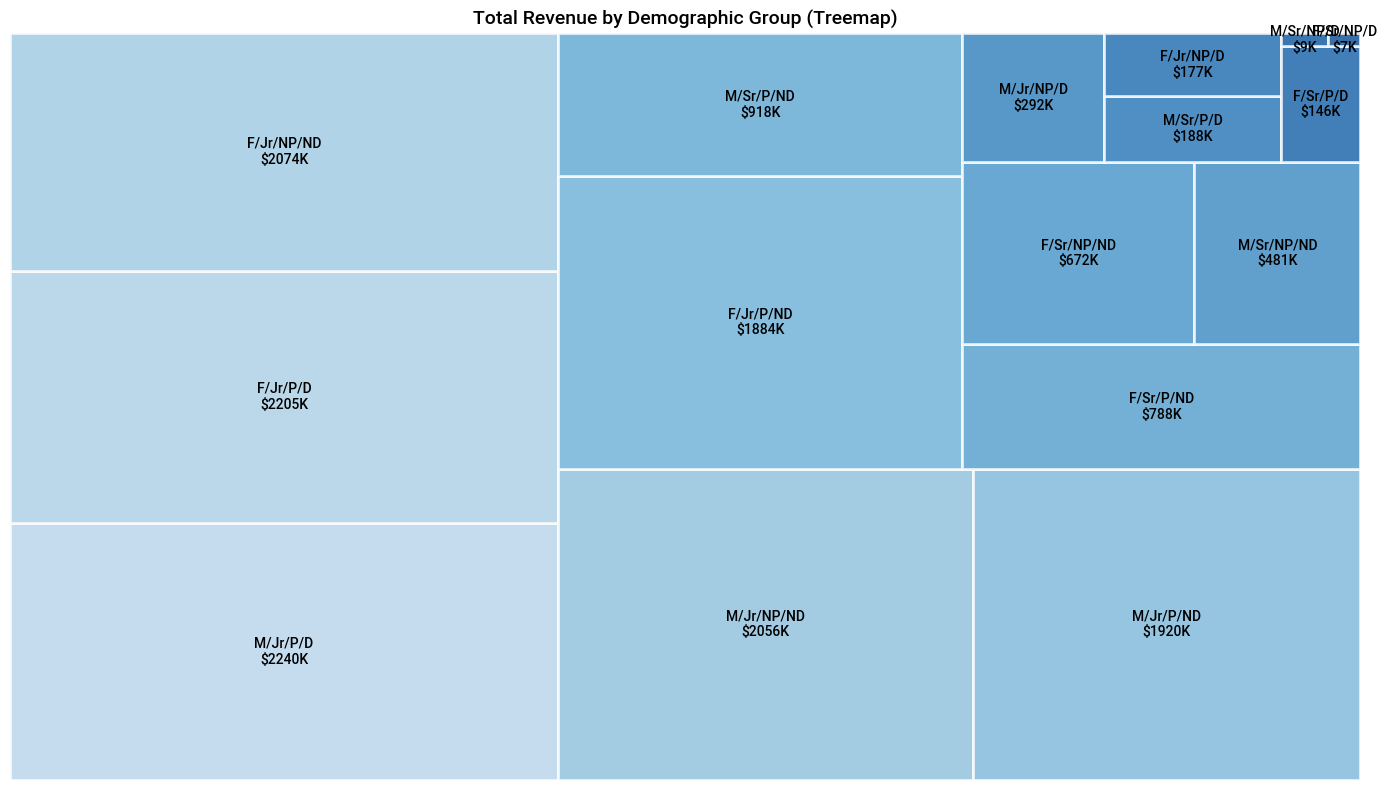

In [15]:
# Plot 5: Treemap - Total Revenue by Demographic Group
import squarify

# Prepare data for treemap
treemap_data = churn_dt.groupby(['gender', 'SeniorCitizen', 'Partner', 'Dependents']).agg(
    total_charges=('TotalCharges', 'sum')
).reset_index()

# Create demographic labels
treemap_data['demo_label'] = (
    treemap_data['gender'].map({1: 'F', 0: 'M'}) + '/' +
    treemap_data['SeniorCitizen'].map({1: 'Sr', 0: 'Jr'}) + '/' +
    treemap_data['Partner'].map({1: 'P', 0: 'NP'}) + '/' +
    treemap_data['Dependents'].map({1: 'D', 0: 'ND'})
)

# Sort by total charges descending
treemap_data = treemap_data.sort_values('total_charges', ascending=False)

# Create labels with values
labels = [f"{label}\n${value/1000:.0f}K" for label, value in 
          zip(treemap_data['demo_label'], treemap_data['total_charges'])]

# Plot treemap
plt.figure(figsize=(14, 8))
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(treemap_data)))
squarify.plot(sizes=treemap_data['total_charges'], label=labels, color=colors, 
              alpha=0.8, edgecolor='white', linewidth=2, text_kwargs={'fontsize': 10})
plt.title('Total Revenue by Demographic Group (Treemap)', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

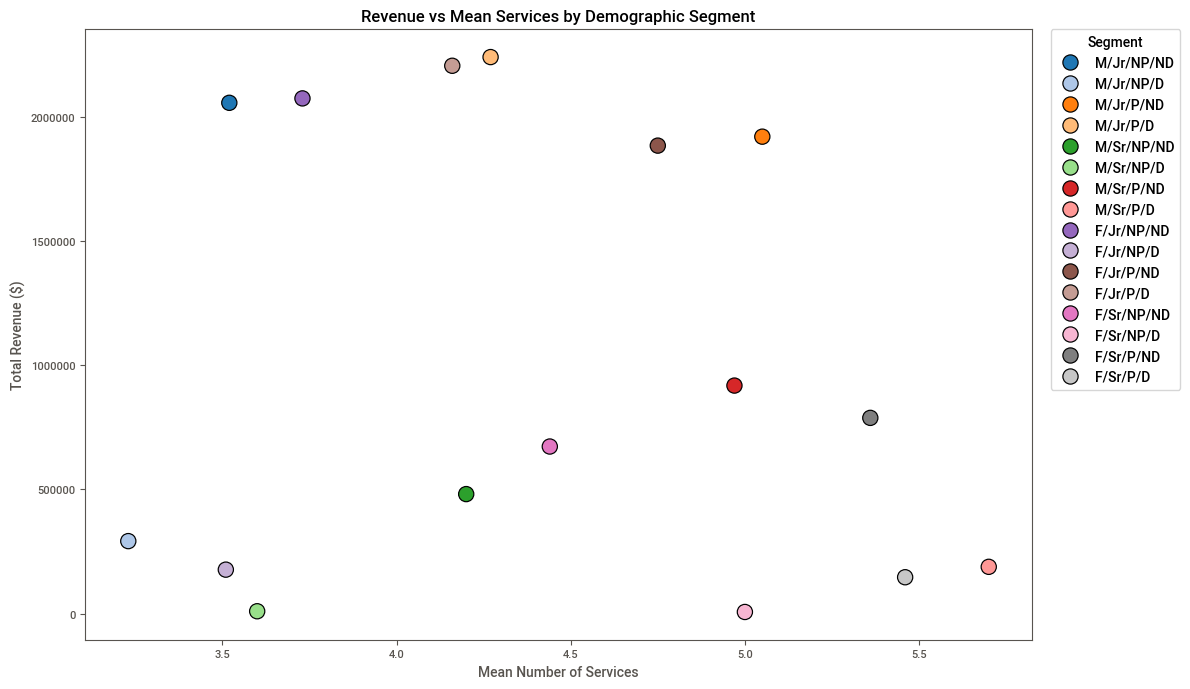

In [16]:
# Scatter: Mean Services vs Total Revenue by Demographic Segment
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure required columns exist
assert 'avg_services' in demo_group.columns and 'total_revenue' in demo_group.columns, "Expected aggregated columns missing."

plt.figure(figsize=(12, 7))
scatter = sns.scatterplot(
    data=demo_group,
    x='avg_services',
    y='total_revenue',
    hue='demo_label',
    palette='tab20',
    s=120,
    edgecolor='black'
)
plt.xlabel('Mean Number of Services')
plt.ylabel('Total Revenue ($)')
plt.title('Revenue vs Mean Services by Demographic Segment')
plt.legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### DQ4. Is service bundling associated with higher customer value?
- Do customers with a higher number of subscribed services have higher total and monthly charges?
- Does service bundling appear to be linked to longer customer lifetime value?


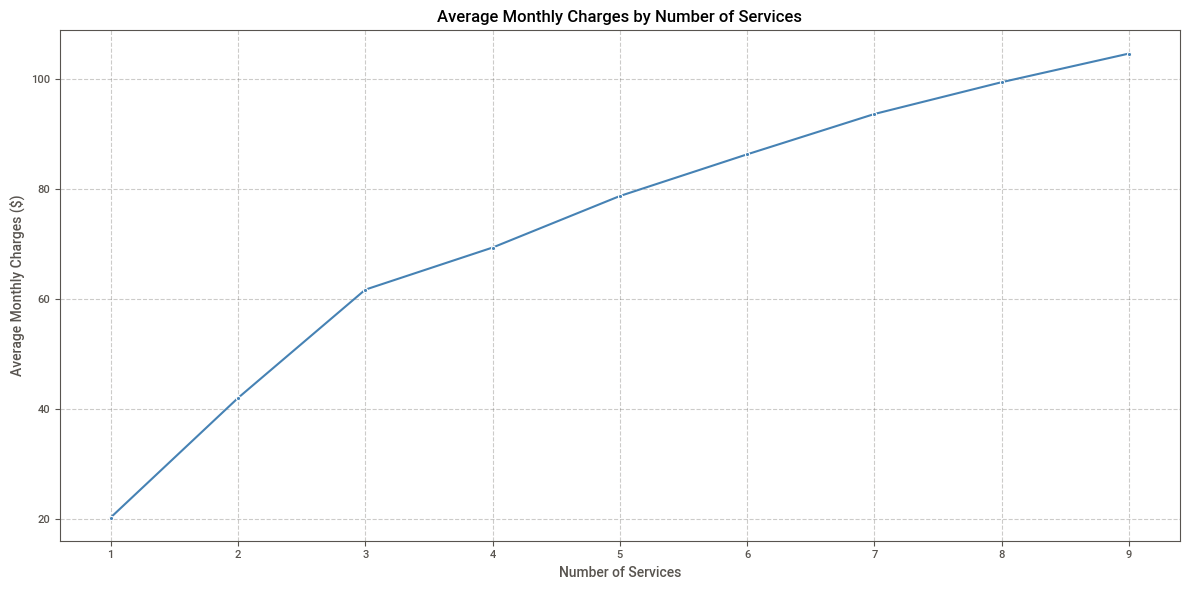

In [17]:
# Line Plot: Average Monthly Charges by Number of Services
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure required columns exist
assert 'total_services' in churn_dt.columns and 'MonthlyCharges' in churn_dt.columns, "Required columns missing from churn_dt."

# Aggregate: mean MonthlyCharges by total_services
services_monthly = (
    churn_dt.groupby('total_services')['MonthlyCharges']
            .mean()
            .reset_index()
            .sort_values('total_services')
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=services_monthly,
    x='total_services',
    y='MonthlyCharges',
    marker='o',
    color='steelblue'
)
plt.xlabel('Number of Services')
plt.ylabel('Average Monthly Charges ($)')
plt.title('Average Monthly Charges by Number of Services')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/72/fp6wrfpj3yz_61z312xbn6kr0000gn/T/ipykernel_87080/670768505.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/72/fp6wrfpj3yz_61z312xbn6kr0000gn/T/ipykernel_87080/670768505.py:8: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='count'` for the same effect.
  sns.violinplot(


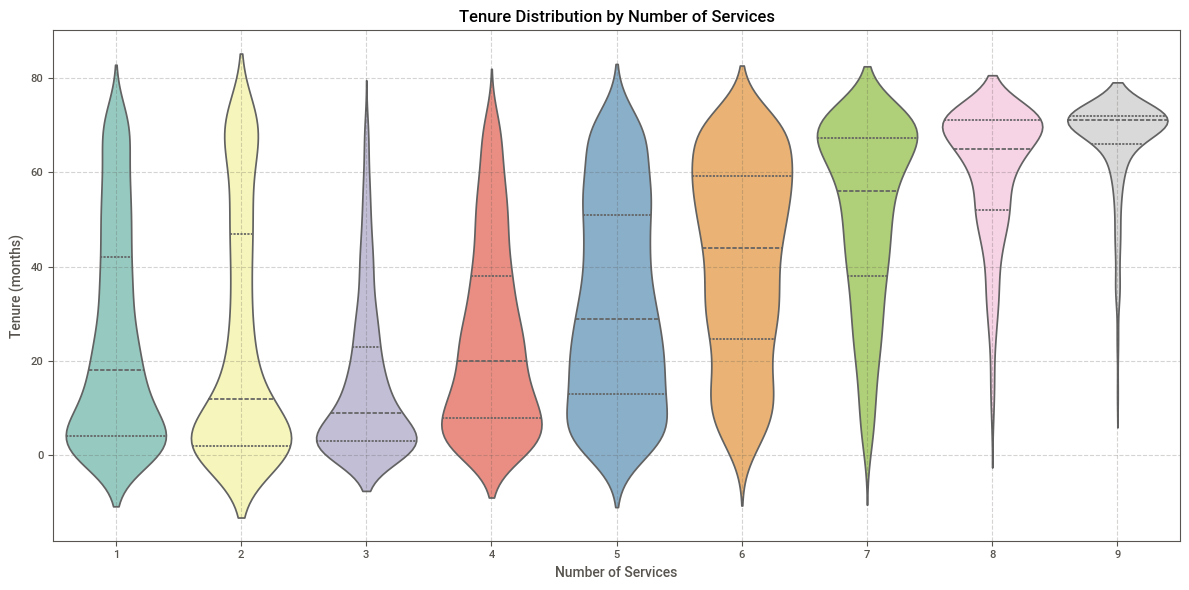

In [18]:
# Tenure Distribution by Number of Services (Violin Plot)
import matplotlib.pyplot as plt
import seaborn as sns

assert 'total_services' in churn_dt.columns and 'tenure' in churn_dt.columns

plt.figure(figsize=(12, 6))
sns.violinplot(
    data=churn_dt,
    x='total_services',
    y='tenure',
    scale='count',
    inner='quartile',
    palette='Set3'
)
plt.xlabel('Number of Services')
plt.ylabel('Tenure (months)')
plt.title('Tenure Distribution by Number of Services')
plt.grid(True, linestyle='--', alpha=0.25)
plt.tight_layout()
plt.show()

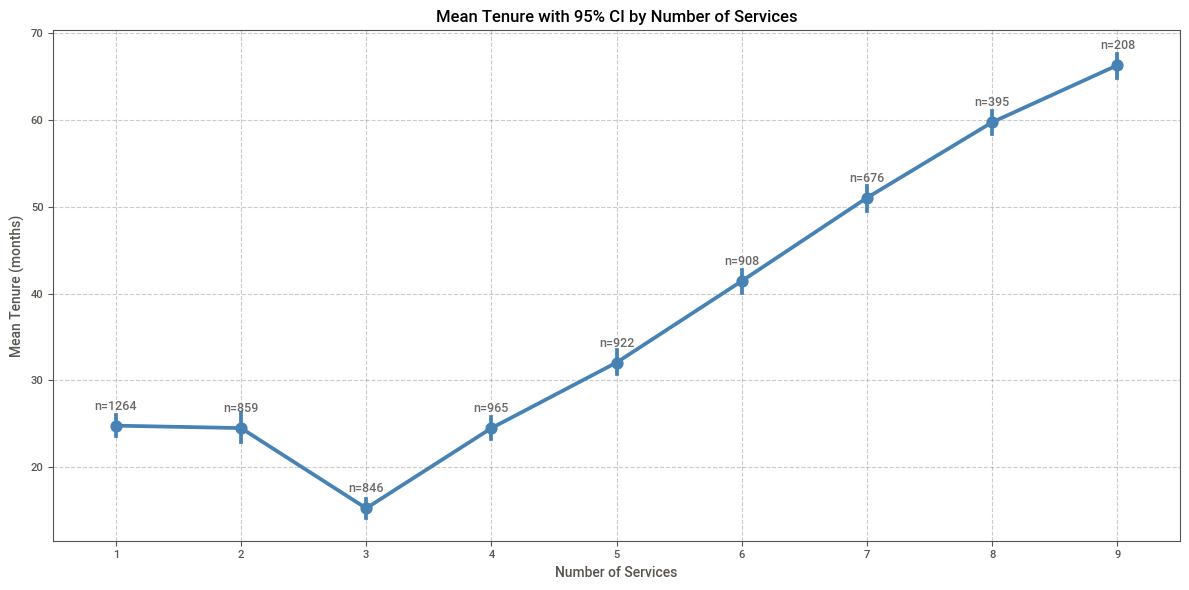

In [19]:
# Mean Tenure with 95% CI by Number of Services
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

assert 'total_services' in churn_dt.columns and 'tenure' in churn_dt.columns

services_tenure_stats = (
    churn_dt.groupby('total_services').agg(
        mean_tenure=('tenure', 'mean'),
        median_tenure=('tenure', 'median'),
        count=('tenure', 'size')
    ).reset_index().sort_values('total_services')
)

plt.figure(figsize=(12, 6))
ax = sns.pointplot(
    data=churn_dt,
    x='total_services',
    y='tenure',
    estimator=np.mean,
    errorbar=('ci', 95),
    color='steelblue',
    markers='o',
    linestyles='-'
)

# Annotate sample sizes near each mean
unique_services = services_tenure_stats['total_services'].tolist()
for idx, svc in enumerate(unique_services):
    m = services_tenure_stats.loc[services_tenure_stats['total_services'] == svc, 'mean_tenure'].values[0]
    n = int(services_tenure_stats.loc[services_tenure_stats['total_services'] == svc, 'count'].values[0])
    ax.text(idx, m + 1.5, f"n={n}", ha='center', va='bottom', fontsize=9, color='dimgray')

plt.xlabel('Number of Services')
plt.ylabel('Mean Tenure (months)')
plt.title('Mean Tenure with 95% CI by Number of Services')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### DQ5. Are there observable demographic patterns that may be associated with churn risk?
- Do specific demographic profiles appear to have lower service adoption and lower total charges?
- Could these profiles indicate potentially higher churn risk?




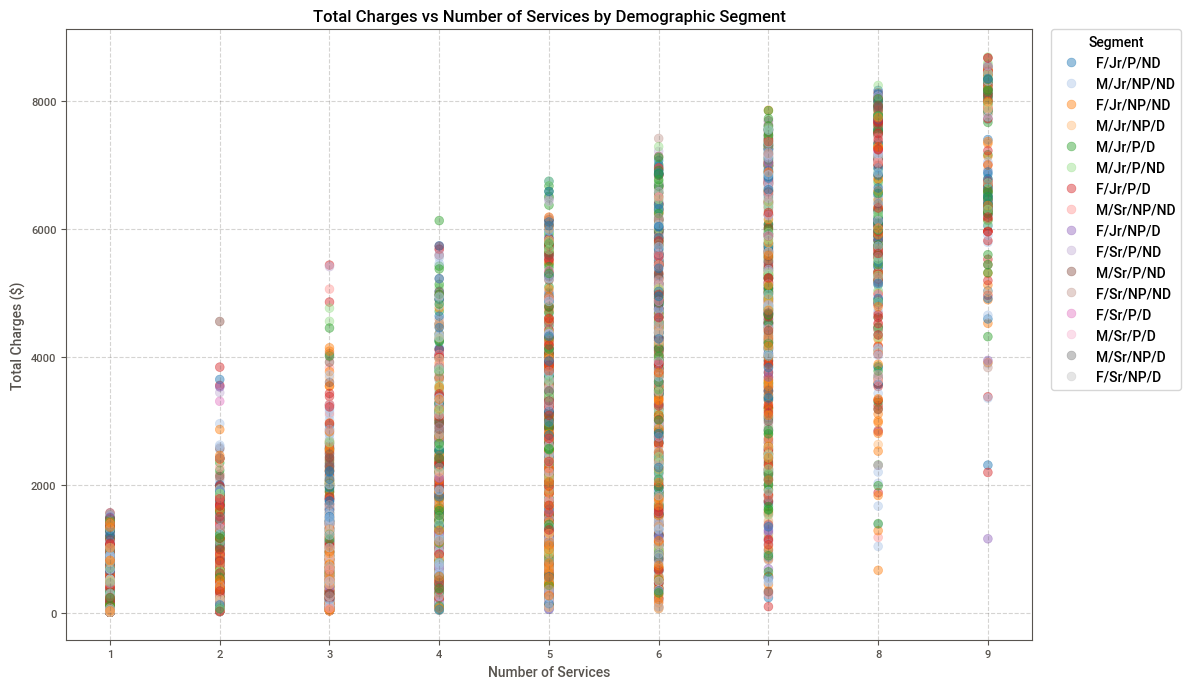

In [20]:
# Scatter: Total Charges vs Number of Services by Demographic Segment
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare data: drop missing TotalCharges or demo_label
assert 'total_services' in churn_dt.columns and 'TotalCharges' in churn_dt.columns and 'demo_label' in churn_dt.columns, "Required columns missing."
plot_df = churn_dt[['total_services', 'TotalCharges', 'demo_label']].dropna()

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=plot_df,
    x='total_services',
    y='TotalCharges',
    hue='demo_label',
    palette='tab20',
    s=40,
    alpha=0.45,
    edgecolor=None
)
plt.xlabel('Number of Services')
plt.ylabel('Total Charges ($)')
plt.title('Total Charges vs Number of Services by Demographic Segment')
plt.legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.25)
plt.tight_layout()
plt.show()

/var/folders/72/fp6wrfpj3yz_61z312xbn6kr0000gn/T/ipykernel_87080/2149096182.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


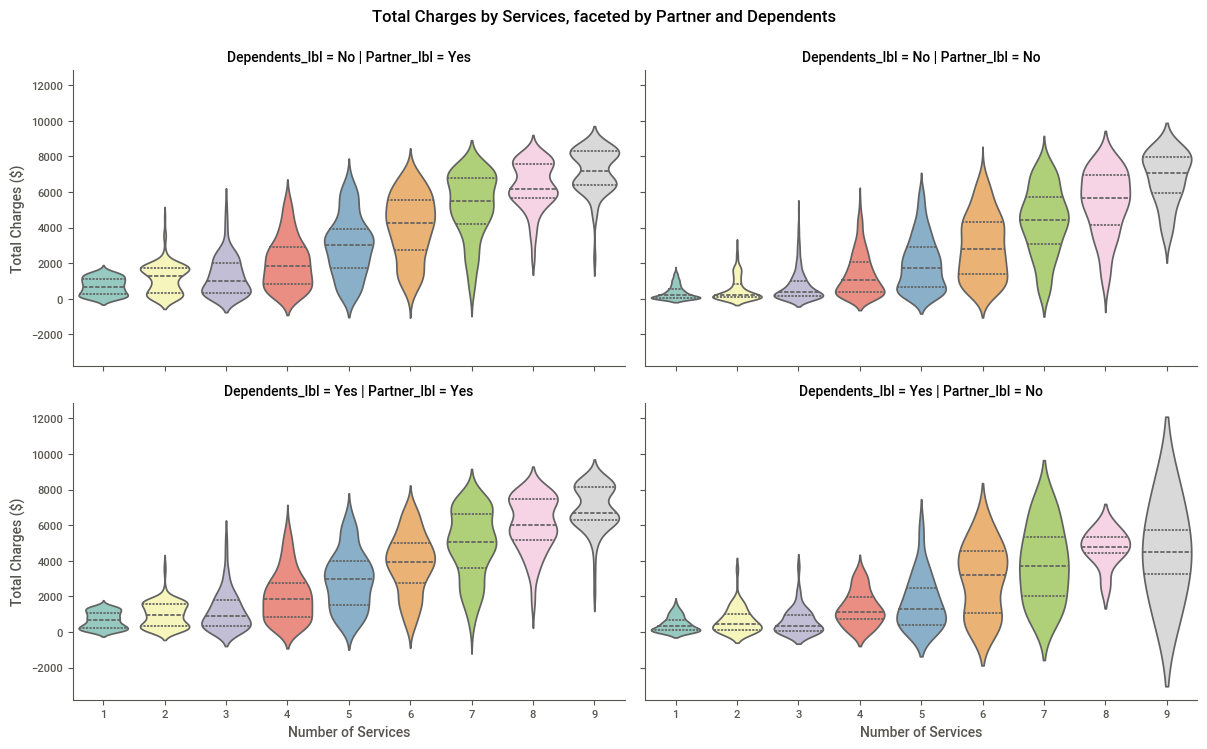

/var/folders/72/fp6wrfpj3yz_61z312xbn6kr0000gn/T/ipykernel_87080/2149096182.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g2 = sns.catplot(


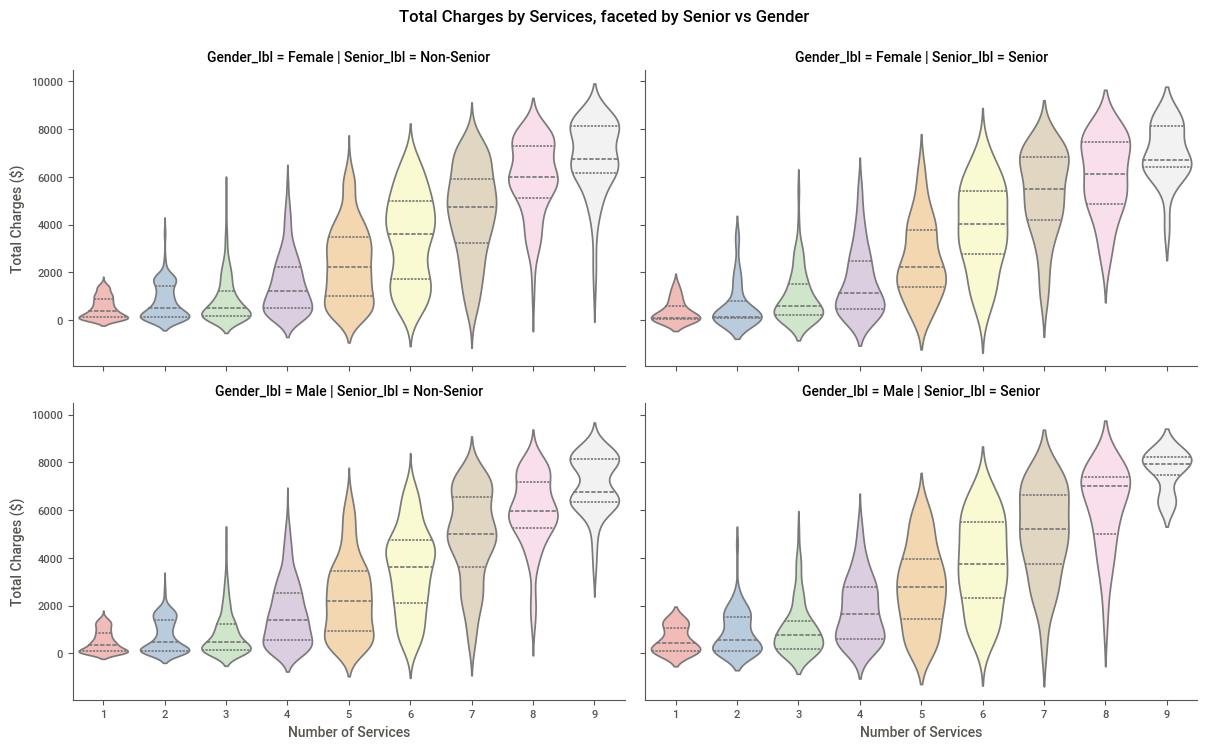

In [21]:
# Violin: Total Charges by Services, Faceted by Demographics
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure required columns
required_cols = {'total_services','TotalCharges','Partner','Dependents','SeniorCitizen','gender'}
assert required_cols.issubset(churn_dt.columns), f"Missing columns: {required_cols - set(churn_dt.columns)}"

# Prepare labeled copies for readable facets
df = churn_dt.copy()
df['Partner_lbl'] = df['Partner'].map({1:'Yes',0:'No'})
df['Dependents_lbl'] = df['Dependents'].map({1:'Yes',0:'No'})
df['Senior_lbl'] = df['SeniorCitizen'].map({1:'Senior',0:'Non-Senior'})
df['Gender_lbl'] = df['gender'].map({1:'Female',0:'Male'})

# Facet 1: Partner x Dependents
g = sns.catplot(
    data=df.dropna(subset=['TotalCharges']),
    x='total_services',
    y='TotalCharges',
    kind='violin',
    col='Partner_lbl',
    row='Dependents_lbl',
    inner='quartile',
    density_norm='count',
    height=3.8,
    aspect=1.6,
    palette='Set3',
    sharey=True
)
g.set_axis_labels('Number of Services','Total Charges ($)')
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Total Charges by Services, faceted by Partner and Dependents')
plt.show()

# Facet 2: SeniorCitizen x Gender
g2 = sns.catplot(
    data=df.dropna(subset=['TotalCharges']),
    x='total_services',
    y='TotalCharges',
    kind='violin',
    col='Senior_lbl',
    row='Gender_lbl',
    inner='quartile',
    density_norm='count',
    height=3.8,
    aspect=1.6,
    palette='Pastel1',
    sharey=True
)
g2.set_axis_labels('Number of Services','Total Charges ($)')
g2.fig.subplots_adjust(top=0.9)
g2.fig.suptitle('Total Charges by Services, faceted by Senior vs Gender')
plt.show()